# TCGA Cancer Genomics — Preprocessing & Exploratory Data Analysis

This notebook performs preprocessing and EDA on **TCGA (The Cancer Genome Atlas)** datasets for four cancer types:

| Abbreviation | Cancer Type |
|---|---|
| **GBM** | Glioblastoma Multiforme (Brain) |
| **LIHC** | Liver Hepatocellular Carcinoma |
| **PAAD** | Pancreatic Adenocarcinoma |
| **SKCM** | Skin Cutaneous Melanoma |

**Data modalities analysed:**
- Clinical patient & sample metadata
- mRNA gene expression (RNA-Seq V2 RSEM)
- Somatic mutations
- Copy-number alterations (CNA)

## 1. Import Required Libraries

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting defaults
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'data'
CANCER_TYPES = ['gbm_tcga', 'lihc_tcga', 'paad_tcga', 'skcm_tcga']
CANCER_LABELS = {'gbm_tcga': 'GBM', 'lihc_tcga': 'LIHC', 'paad_tcga': 'PAAD', 'skcm_tcga': 'SKCM'}

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Data from Directory

We load the core data files for each cancer type:
- **Clinical patient data** — demographics, diagnosis, survival
- **Clinical sample data** — sample metadata, cancer type details
- **mRNA expression** — RNA-Seq V2 RSEM (genes × samples)
- **Mutations** — somatic mutations (MAF-like format)
- **CNA** — copy-number alterations per gene per sample

In [2]:
# Helper: load a TCGA cBioPortal-style clinical file (skip comment lines starting with #)
def load_clinical(filepath):
    """Load a cBioPortal clinical file, skipping header comment lines."""
    # Count comment lines
    with open(filepath) as f:
        skip = 0
        for line in f:
            if line.startswith('#'):
                skip += 1
            else:
                break
    return pd.read_csv(filepath, sep='\t', skiprows=skip, na_values=['[Not Available]', '[Not Applicable]', '[Not Evaluated]', '[Pending]'])

# ----- Load clinical patient data -----
clinical_patient = {}
for ct in CANCER_TYPES:
    fp = os.path.join(DATA_DIR, ct, 'data_clinical_patient.txt')
    df = load_clinical(fp)
    df['CANCER_TYPE'] = CANCER_LABELS[ct]
    clinical_patient[ct] = df
    print(f"{CANCER_LABELS[ct]:>5}: {df.shape[0]:>4} patients, {df.shape[1]} columns")

clinical_all = pd.concat(clinical_patient.values(), ignore_index=True)
print(f"\n{'TOTAL':>5}: {clinical_all.shape[0]} patients across all cancer types")
clinical_all.head(3)

  GBM:  596 patients, 39 columns
 LIHC:  377 patients, 75 columns
 PAAD:  185 patients, 75 columns
 SKCM:  470 patients, 61 columns

TOTAL: 1628 patients across all cancer types


,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,HISTORY_LGG_DX_OF_BRAIN_TISSUE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,RACE,ETHNICITY,HISTORY_OTHER_MALIGNANCY,...,IDH_LEVEL,SUBMITTED_TUMOR_DX_DAYS_TO,TUMOR_SITE,METASTATIC_SITE_PATIENT,PRIMARY_MELANOMA_SKIN_TYPE,HISTORY_NEOADJUVANT_TX_TYPE,IFN_TX_90_DAYS_PRIOR_TO_RESECTION,NEW_TUMOR_EVENT_PRIOR_TO_BCR_TUMOR,NEW_TUMOR_EVENT_MELANOMA_COUNT,TUMOR_TISSUE_SITE_OTHER
0,30a1fe5e-5b12-472c-aa86-c2db8167ab23,TCGA-02-0001,12/16/08,NO,NaN,NaN,Female,WHITE,NOT HISPANIC OR LATINO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,df3c1d61-79c1-43e9-971a-8029497ffeab,TCGA-02-0003,12/16/08,NO,NaN,NaN,Male,WHITE,NOT HISPANIC OR LATINO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3ac8f759-2df0-4ef5-913f-ce05b8dd8937,TCGA-02-0004,12/17/08,NO,NaN,NaN,Male,WHITE,NOT HISPANIC OR LATINO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ----- Load clinical sample data -----
clinical_sample = {}
for ct in CANCER_TYPES:
    fp = os.path.join(DATA_DIR, ct, 'data_clinical_sample.txt')
    df = load_clinical(fp)
    df['CANCER_TYPE'] = CANCER_LABELS[ct]
    clinical_sample[ct] = df
    print(f"{CANCER_LABELS[ct]:>5}: {df.shape[0]:>4} samples, {df.shape[1]} columns")

sample_all = pd.concat(clinical_sample.values(), ignore_index=True)
print(f"\n{'TOTAL':>5}: {sample_all.shape[0]} samples")
sample_all.head(3)

  GBM:  619 samples, 27 columns
 LIHC:  379 samples, 27 columns
 PAAD:  186 samples, 27 columns
 SKCM:  480 samples, 27 columns

TOTAL: 1664 samples


,PATIENT_ID,SAMPLE_ID,OTHER_SAMPLE_ID,SPECIMEN_CURRENT_WEIGHT,DAYS_TO_COLLECTION,DAYS_TO_SPECIMEN_COLLECTION,SPECIMEN_FREEZING_METHOD,SAMPLE_INITIAL_WEIGHT,SPECIMEN_SECOND_LONGEST_DIMENSION,IS_FFPE,...,SAMPLE_TYPE_ID,SHORTEST_DIMENSION,TIME_BETWEEN_CLAMPING_AND_FREEZING,TIME_BETWEEN_EXCISION_AND_FREEZING,VIAL_NUMBER,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,TCGA-02-0001,TCGA-02-0001-01,3df90f1c-94da-4bd5-bd8e-a0bc92d715f9,NaN,NaN,NaN,NaN,NaN,0.7,NO,...,1,0.2,NaN,NaN,C,GBM,GBM,Glioblastoma Multiforme,Matched,NaN
1,TCGA-02-0003,TCGA-02-0003-01,123ebb05-33c0-441c-9549-262433b14810,NaN,NaN,NaN,NaN,NaN,0.9,NO,...,1,0.1,NaN,NaN,A,GBM,GBM,Glioblastoma Multiforme,Matched,1.566667
2,TCGA-02-0006,TCGA-02-0006-01,03c9930f-7695-419a-bf24-184be75aea63,NaN,NaN,NaN,NaN,NaN,1.3,NO,...,1,0.1,NaN,NaN,B,GBM,GBM,Glioblastoma Multiforme,Matched,NaN


In [4]:
# ----- Load mRNA expression data (RNA-Seq V2 RSEM) -----
# These are large matrices: genes (rows) × samples (columns)
expr_data = {}
for ct in CANCER_TYPES:
    fp = os.path.join(DATA_DIR, ct, 'data_mrna_seq_v2_rsem.txt')
    df = pd.read_csv(fp, sep='\t')
    df = df.drop(columns=['Entrez_Gene_Id'], errors='ignore')
    df = df.set_index('Hugo_Symbol')
    # Remove duplicate gene names (keep first)
    df = df[~df.index.duplicated(keep='first')]
    expr_data[ct] = df
    print(f"{CANCER_LABELS[ct]:>5}: {df.shape[0]:>6} genes × {df.shape[1]:>4} samples")

print(f"\nGenes shared across all 4 datasets: {len(set.intersection(*[set(df.index) for df in expr_data.values()]))}")

  GBM:  20514 genes ×  166 samples
 LIHC:  20514 genes ×  373 samples
 PAAD:  20514 genes ×  179 samples
 SKCM:  20514 genes ×  472 samples

Genes shared across all 4 datasets: 20506


In [5]:
# ----- Load mutation data -----
mutation_data = {}
for ct in CANCER_TYPES:
    fp = os.path.join(DATA_DIR, ct, 'data_mutations.txt')
    df = pd.read_csv(fp, sep='\t', low_memory=False)
    mutation_data[ct] = df
    print(f"{CANCER_LABELS[ct]:>5}: {df.shape[0]:>7} mutations, {df.shape[1]} columns")

# ----- Load CNA data -----
cna_data = {}
for ct in CANCER_TYPES:
    fp = os.path.join(DATA_DIR, ct, 'data_cna.txt')
    df = pd.read_csv(fp, sep='\t')
    df = df.drop(columns=['Entrez_Gene_Id'], errors='ignore')
    df = df.set_index('Hugo_Symbol')
    df = df[~df.index.duplicated(keep='first')]
    cna_data[ct] = df
    print(f"{CANCER_LABELS[ct]:>5}: {df.shape[0]:>6} genes × {df.shape[1]:>4} samples (CNA)")

  GBM:   22073 mutations, 90 columns
 LIHC:   53777 mutations, 62 columns
 PAAD:   30357 mutations, 251 columns
 SKCM:  324158 mutations, 97 columns
  GBM:  24764 genes ×  577 samples (CNA)
 LIHC:  24765 genes ×  370 samples (CNA)
 PAAD:  24765 genes ×  184 samples (CNA)
 SKCM:  24765 genes ×  367 samples (CNA)


## 3. Initial Data Inspection

Examine shapes, data types, and summary statistics of the combined clinical dataset.

In [6]:
# --- Clinical patient data overview ---
print("=" * 60)
print("CLINICAL PATIENT DATA — Combined")
print("=" * 60)
print(f"Shape: {clinical_all.shape}")
print(f"\nColumn names:\n{list(clinical_all.columns)}\n")
print("Data types:")
print(clinical_all.dtypes.value_counts())
print("\nNumeric summary:")
clinical_all.describe()

CLINICAL PATIENT DATA — Combined
Shape: (1628, 127)

Column names:
['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'HISTORY_LGG_DX_OF_BRAIN_TISSUE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY', 'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN', 'INITIAL_PATHOLOGIC_DX_YEAR', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'TUMOR_STATUS', 'KARNOFSKY_PERFORMANCE_SCORE', 'ECOG_SCORE', 'PERFORMANCE_STATUS_TIMING', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT', 'TREATMENT_OUTCOME_FIRST_COURSE', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'AGE', 'PRIMARY_SITE_PATIENT', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'DISEASE_CODE', 'HISTOLOGICAL_DIAGNOSIS', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'PROJECT_CODE', 'TISSUE_SOURCE_SITE', 'SITE_OF_TUMOR_TISSUE', 'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'CANCER_TYPE', 'HEIGHT', 'WEIGHT', 'FAMILY_HISTORY_

,INITIAL_PATHOLOGIC_DX_YEAR,KARNOFSKY_PERFORMANCE_SCORE,ECOG_SCORE,AGE,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DISEASE_CODE,PROJECT_CODE,OS_MONTHS,DFS_MONTHS,HEIGHT,...,SMOKING_PACK_YEARS,ALCOHOL_CONSUMPTION_FREQUENCY,DAILY_ALCOHOL,DIABETES_DIAGNOSIS_DAYS_TO,HISTORY_CHRONIC_PANCREATITIS_DAYS_TO,DAYS_TO_PATIENT_PROGRESSION_FREE,DAYS_TO_TUMOR_PROGRESSION,PRIMARY_AT_DX_COUNT,BRESLOW_DEPTH,PRIMARY_MELANOMA_MITOTIC_RATE
count,1247.000000,439.000000,366.000000,1619.000000,1618.0,0.0,0.0,1616.000000,1303.000000,598.000000,...,57.000000,32.000000,31.000000,14.000000,11.000000,0.0,0.0,172.000000,359.000000,172.000000
mean,2006.106656,77.107062,0.748634,59.121062,0.0,NaN,NaN,31.592791,25.795963,168.563545,...,26.840351,4.812500,1.580645,-706.785714,-1744.181818,NaN,NaN,1.040698,5.584903,6.464477
std,5.790124,15.455487,0.895765,14.411965,0.0,NaN,NaN,42.122137,38.864878,10.225685,...,17.939702,2.425503,0.876516,2416.811987,5402.658194,NaN,NaN,0.250323,8.444314,6.789760
min,1978.000000,0.000000,0.000000,10.000000,0.0,NaN,NaN,-0.070000,-0.070000,64.000000,...,0.300000,0.500000,0.500000,-9070.000000,-18029.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,2003.000000,70.000000,0.000000,50.000000,0.0,NaN,NaN,9.400000,5.535000,162.000000,...,15.000000,3.000000,1.000000,-163.000000,-231.500000,NaN,NaN,1.000000,1.300000,2.000000
50%,2008.000000,80.000000,1.000000,60.000000,0.0,NaN,NaN,17.165000,12.420000,168.000000,...,25.000000,6.500000,1.000000,-52.000000,-71.000000,NaN,NaN,1.000000,3.000000,5.000000
75%,2010.000000,80.000000,1.000000,70.000000,0.0,NaN,NaN,35.750000,27.300000,175.000000,...,40.000000,7.000000,2.000000,-17.750000,-38.000000,NaN,NaN,1.000000,6.950000,9.000000
max,2013.000000,100.000000,4.000000,90.000000,0.0,NaN,NaN,369.650000,368.500000,196.000000,...,75.000000,7.000000,4.000000,504.000000,1.000000,NaN,NaN,3.000000,75.000000,40.000000


In [7]:
# --- Per-cancer-type patient counts and key column inspection ---
print("Patients per cancer type:")
print(clinical_all['CANCER_TYPE'].value_counts())
print()

# Key clinical columns of interest
KEY_COLS = ['PATIENT_ID', 'SEX', 'RACE', 'ETHNICITY', 'AGE',
            'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'CANCER_TYPE']
available_keys = [c for c in KEY_COLS if c in clinical_all.columns]
print(f"Key columns available: {available_keys}")
clinical_all[available_keys].head(10)

Patients per cancer type:
CANCER_TYPE
GBM     596
SKCM    470
LIHC    377
PAAD    185
Name: count, dtype: int64

Key columns available: ['PATIENT_ID', 'SEX', 'RACE', 'ETHNICITY', 'AGE', 'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'CANCER_TYPE']


,PATIENT_ID,SEX,RACE,ETHNICITY,AGE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS,CANCER_TYPE
0,TCGA-02-0001,Female,WHITE,NOT HISPANIC OR LATINO,44.0,1:DECEASED,11.76,1:Recurred/Progressed,4.50,GBM
1,TCGA-02-0003,Male,WHITE,NOT HISPANIC OR LATINO,50.0,1:DECEASED,4.73,1:Recurred/Progressed,1.31,GBM
2,TCGA-02-0004,Male,WHITE,NOT HISPANIC OR LATINO,59.0,1:DECEASED,11.33,1:Recurred/Progressed,10.32,GBM
3,TCGA-02-0006,Female,WHITE,NOT HISPANIC OR LATINO,56.0,1:DECEASED,18.33,1:Recurred/Progressed,9.92,GBM
4,TCGA-02-0007,Female,WHITE,NOT HISPANIC OR LATINO,40.0,1:DECEASED,23.16,1:Recurred/Progressed,17.02,GBM
5,TCGA-02-0009,Female,WHITE,NOT HISPANIC OR LATINO,61.0,1:DECEASED,10.58,1:Recurred/Progressed,8.67,GBM
6,TCGA-02-0010,Female,WHITE,NOT HISPANIC OR LATINO,20.0,1:DECEASED,35.38,1:Recurred/Progressed,11.53,GBM
7,TCGA-02-0011,Female,WHITE,HISPANIC OR LATINO,18.0,1:DECEASED,20.70,1:Recurred/Progressed,4.76,GBM
8,TCGA-02-0014,Male,WHITE,NOT HISPANIC OR LATINO,25.0,1:DECEASED,82.52,1:Recurred/Progressed,73.69,GBM
9,TCGA-02-0015,Male,WHITE,NOT HISPANIC OR LATINO,50.0,1:DECEASED,20.60,1:Recurred/Progressed,14.98,GBM


In [8]:
# --- Gene expression data snapshot ---
print("mRNA Expression data (RNA-Seq V2 RSEM) — snapshot per cancer type:\n")
for ct in CANCER_TYPES:
    df = expr_data[ct]
    print(f"{CANCER_LABELS[ct]}: {df.shape[0]} genes × {df.shape[1]} samples")
    print(f"  Value range: [{df.min().min():.2f}, {df.max().max():.2f}]")
    print(f"  % zeros: {(df == 0).sum().sum() / df.size * 100:.1f}%")
    print(f"  Missing values: {df.isnull().sum().sum()}\n")

mRNA Expression data (RNA-Seq V2 RSEM) — snapshot per cancer type:

GBM: 20514 genes × 166 samples
  Value range: [0.00, 1026361.21]
  % zeros: 14.3%
  Missing values: 0

LIHC: 20514 genes × 373 samples
  Value range: [0.00, 7092441.51]
  % zeros: 17.8%
  Missing values: 0

PAAD: 20514 genes × 179 samples
  Value range: [0.00, 6699496.78]
  % zeros: 12.8%
  Missing values: 0

SKCM: 20514 genes × 472 samples
  Value range: [0.00, 3390700.79]
  % zeros: 16.2%
  Missing values: 0



## 4. Handle Missing Values

Identify and visualise missingness in the clinical data, then apply imputation strategies.

Columns with missing values: 117 / 127



,Missing Count,Missing %
DISEASE_CODE,1628,100.0
PROJECT_CODE,1628,100.0
CLIN_N_STAGE,1628,100.0
CLIN_M_STAGE,1628,100.0
CLIN_T_STAGE,1628,100.0
DAYS_TO_PATIENT_PROGRESSION_FREE,1628,100.0
DAYS_TO_TUMOR_PROGRESSION,1628,100.0
STAGE_OTHER,1628,100.0
EXTRANODAL_INVOLVEMENT,1628,100.0
CLINICAL_STAGE,1628,100.0


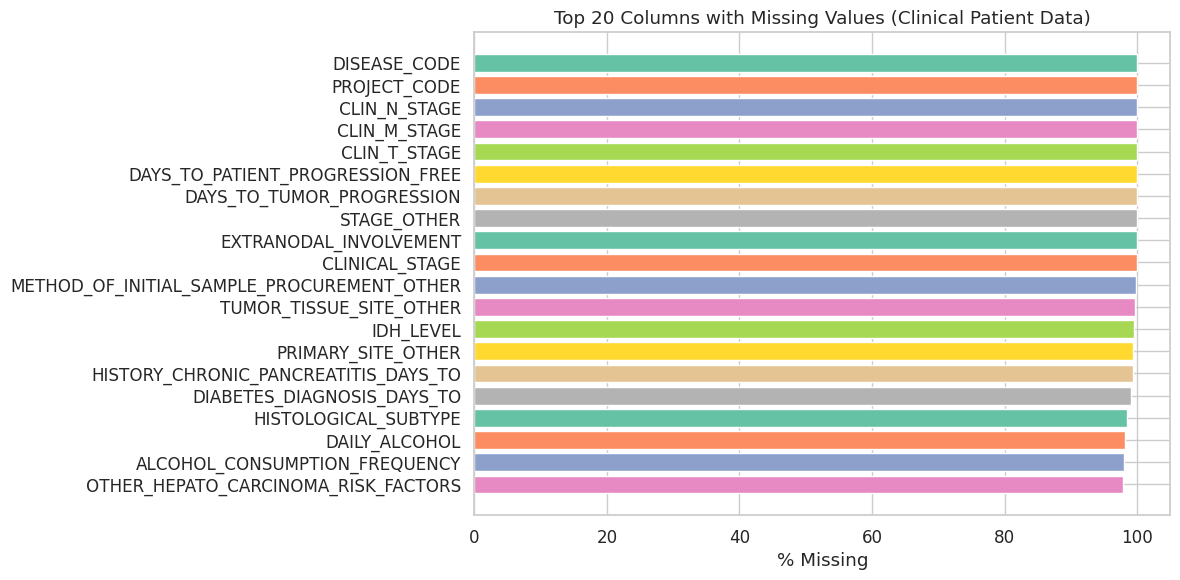

In [9]:
# --- Missing value overview for clinical patient data ---
missing = clinical_all.isnull().sum()
missing_pct = (missing / len(clinical_all) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing values: {len(missing_df)} / {clinical_all.shape[1]}\n")
display(missing_df.head(20))

# Visualize missing values for the top columns
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_df.head(20)
ax.barh(top_missing.index, top_missing['Missing %'], color=sns.color_palette("Set2", len(top_missing)))
ax.set_xlabel('% Missing')
ax.set_title('Top 20 Columns with Missing Values (Clinical Patient Data)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# --- Apply missing value strategies to the clinical data ---

# Drop columns that are >80% missing
high_missing_cols = missing_df[missing_df['Missing %'] > 80].index.tolist()
print(f"Dropping {len(high_missing_cols)} columns with >80% missing: {high_missing_cols}")
clinical_clean = clinical_all.drop(columns=high_missing_cols, errors='ignore')

# For numeric columns with moderate missingness, impute with median
numeric_cols = clinical_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if clinical_clean[col].isnull().sum() > 0:
        median_val = clinical_clean[col].median()
        clinical_clean[col] = clinical_clean[col].fillna(median_val)
        print(f"  Imputed '{col}' with median = {median_val:.2f}")

# For categorical columns, fill with 'Unknown'
cat_cols = clinical_clean.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    n_miss = clinical_clean[col].isnull().sum()
    if n_miss > 0:
        clinical_clean[col] = clinical_clean[col].fillna('Unknown')

print(f"\nRemaining missing values: {clinical_clean.isnull().sum().sum()}")
print(f"Cleaned clinical data shape: {clinical_clean.shape}")

Dropping 74 columns with >80% missing: ['DISEASE_CODE', 'PROJECT_CODE', 'CLIN_N_STAGE', 'CLIN_M_STAGE', 'CLIN_T_STAGE', 'DAYS_TO_PATIENT_PROGRESSION_FREE', 'DAYS_TO_TUMOR_PROGRESSION', 'STAGE_OTHER', 'EXTRANODAL_INVOLVEMENT', 'CLINICAL_STAGE', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'TUMOR_TISSUE_SITE_OTHER', 'IDH_LEVEL', 'PRIMARY_SITE_OTHER', 'HISTORY_CHRONIC_PANCREATITIS_DAYS_TO', 'DIABETES_DIAGNOSIS_DAYS_TO', 'HISTOLOGICAL_SUBTYPE', 'DAILY_ALCOHOL', 'ALCOHOL_CONSUMPTION_FREQUENCY', 'OTHER_HEPATO_CARCINOMA_RISK_FACTORS', 'HISTORY_NEOADJUVANT_TX_TYPE', 'IFN_TX_90_DAYS_PRIOR_TO_RESECTION', 'PATIENT_DEATH_REASON', 'SMOKING_YEAR_STARTED', 'SMOKING_YEAR_STOPPED', 'LYMPH_NODES_EXAMINED_IHC_COUNT', 'SMOKING_PACK_YEARS', 'FAMILY_HISTORY_CANCER_TYPE', 'CAUSE_OF_DEATH_SOURCE', 'ALCOHOL_EXPOSURE_INTENSITY', 'METASTATIC_SITE_PATIENT', 'GRADE_TIER_SYSTEM', 'VASCULAR_INVASION', 'FAMILY_HISTORY_CANCER_NUMBER_RELATIVES', 'HEPATIC_INFLAMMATION_ADJ_TISSUE', 'TREATMENT_OUTCOME_FIRST_COURSE', 'HIS

In [11]:
# --- Handle missing values in gene expression data ---
# Replace NaN with 0 (unexpressed), and log2(x+1) transform for downstream analysis
expr_log2 = {}
for ct in CANCER_TYPES:
    df = expr_data[ct].copy()
    n_missing = df.isnull().sum().sum()
    if n_missing > 0:
        print(f"{CANCER_LABELS[ct]}: Filling {n_missing} missing expression values with 0")
        df = df.fillna(0)
    # Log2(x + 1) transform
    df_log = np.log2(df + 1)
    expr_log2[ct] = df_log
    print(f"{CANCER_LABELS[ct]}: Log2-transformed. Range: [{df_log.min().min():.2f}, {df_log.max().max():.2f}]")

print("\nExpression data preprocessed (NaN→0, log2(x+1) transformed).")

GBM: Log2-transformed. Range: [0.00, 19.97]
LIHC: Log2-transformed. Range: [0.00, 22.76]
PAAD: Log2-transformed. Range: [0.00, 22.68]
SKCM: Log2-transformed. Range: [0.00, 21.69]

Expression data preprocessed (NaN→0, log2(x+1) transformed).


## 5. Handle Duplicates

In [12]:
# --- Check for duplicate patients ---
n_dup_patients = clinical_clean.duplicated(subset=['PATIENT_ID']).sum()
print(f"Duplicate PATIENT_IDs in clinical data: {n_dup_patients}")
if n_dup_patients > 0:
    clinical_clean = clinical_clean.drop_duplicates(subset=['PATIENT_ID'], keep='first')
    print(f"  → Removed duplicates. New shape: {clinical_clean.shape}")

# --- Check for duplicate samples ---
n_dup_samples = sample_all.duplicated(subset=['SAMPLE_ID']).sum()
print(f"Duplicate SAMPLE_IDs in sample data:   {n_dup_samples}")

# --- Check for duplicate genes in expression data ---
for ct in CANCER_TYPES:
    n_dup = expr_log2[ct].index.duplicated().sum()
    print(f"{CANCER_LABELS[ct]} expression — duplicate genes: {n_dup}")

print("\nDuplicate check complete.")

Duplicate PATIENT_IDs in clinical data: 0
Duplicate SAMPLE_IDs in sample data:   0
GBM expression — duplicate genes: 0
LIHC expression — duplicate genes: 0
PAAD expression — duplicate genes: 0
SKCM expression — duplicate genes: 0

Duplicate check complete.


## 6. Data Type Conversion and Formatting

Standardise column names, parse survival status, and convert key columns to appropriate types.

In [13]:
# --- Parse survival status into binary ---
# OS_STATUS format: "0:LIVING" or "1:DECEASED"
if 'OS_STATUS' in clinical_clean.columns:
    clinical_clean['OS_EVENT'] = clinical_clean['OS_STATUS'].apply(
        lambda x: 1 if '1:' in str(x) or 'DECEASED' in str(x).upper() else 0
    )
    print("OS_EVENT distribution:")
    print(clinical_clean['OS_EVENT'].value_counts())

# DFS_STATUS format: "0:DiseaseFree" or "1:Recurred/Progressed"
if 'DFS_STATUS' in clinical_clean.columns:
    clinical_clean['DFS_EVENT'] = clinical_clean['DFS_STATUS'].apply(
        lambda x: 1 if '1:' in str(x) or 'RECURRED' in str(x).upper() or 'PROGRESSED' in str(x).upper() else 0
    )
    print("\nDFS_EVENT distribution:")
    print(clinical_clean['DFS_EVENT'].value_counts())

# Ensure numeric columns are numeric
for col in ['OS_MONTHS', 'DFS_MONTHS', 'AGE']:
    if col in clinical_clean.columns:
        clinical_clean[col] = pd.to_numeric(clinical_clean[col], errors='coerce')

# Convert categorical columns to category dtype
for col in ['SEX', 'RACE', 'ETHNICITY', 'CANCER_TYPE']:
    if col in clinical_clean.columns:
        clinical_clean[col] = clinical_clean[col].astype('category')

print(f"\nClinical data dtypes after conversion:")
print(clinical_clean.dtypes.value_counts())

OS_EVENT distribution:
OS_EVENT
1    947
0    681
Name: count, dtype: int64

DFS_EVENT distribution:
DFS_EVENT
1    904
0    724
Name: count, dtype: int64

Clinical data dtypes after conversion:
str         38
float64     11
int64        2
category     1
category     1
category     1
category     1
Name: count, dtype: int64


## 7. Outlier Detection and Treatment

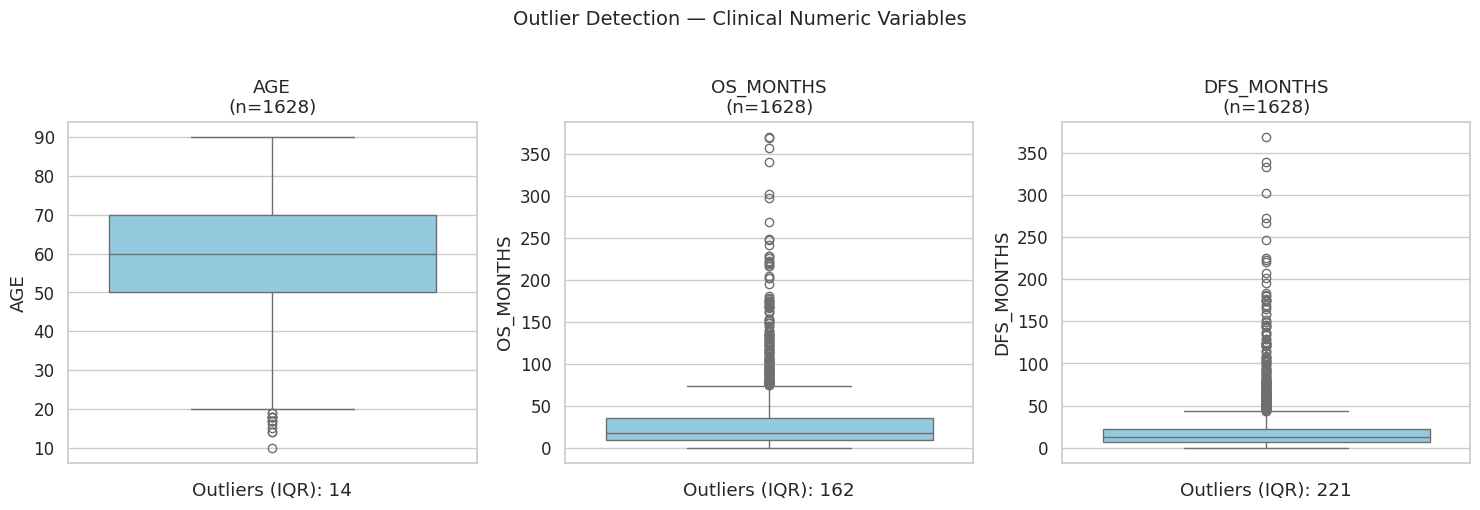

OS_MONTHS: capped 17 values at 99th percentile (218.4 months)
DFS_MONTHS: capped 17 values at 99th percentile (175.6 months)


In [14]:
# --- Outlier detection for key clinical numeric variables ---
outlier_cols = [c for c in ['AGE', 'OS_MONTHS', 'DFS_MONTHS'] if c in clinical_clean.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5 * len(outlier_cols), 5))
if len(outlier_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, outlier_cols):
    data = clinical_clean[col].dropna()
    sns.boxplot(y=data, ax=ax, color='skyblue')
    ax.set_title(f'{col}\n(n={len(data)})')

    # IQR method
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((data < lower) | (data > upper)).sum()
    ax.set_xlabel(f'Outliers (IQR): {n_outliers}')

plt.suptitle('Outlier Detection — Clinical Numeric Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Cap outliers in OS_MONTHS and DFS_MONTHS at 99th percentile (biological plausibility)
for col in ['OS_MONTHS', 'DFS_MONTHS']:
    if col in clinical_clean.columns:
        cap = clinical_clean[col].quantile(0.99)
        n_capped = (clinical_clean[col] > cap).sum()
        clinical_clean[col] = clinical_clean[col].clip(upper=cap)
        print(f"{col}: capped {n_capped} values at 99th percentile ({cap:.1f} months)")

## 8. Feature Engineering

Create derived features from clinical and genomic data for downstream analysis.

In [15]:
# --- Age binning ---
if 'AGE' in clinical_clean.columns:
    clinical_clean['AGE_GROUP'] = pd.cut(
        clinical_clean['AGE'],
        bins=[0, 40, 55, 65, 75, 120],
        labels=['≤40', '41-55', '56-65', '66-75', '>75']
    )
    print("AGE_GROUP distribution:")
    print(clinical_clean['AGE_GROUP'].value_counts().sort_index())

# --- Mutation burden per sample per cancer type ---
mutation_burden = {}
for ct in CANCER_TYPES:
    df = mutation_data[ct]
    if 'Tumor_Sample_Barcode' in df.columns:
        burden = df.groupby('Tumor_Sample_Barcode').size().reset_index(name='MUTATION_COUNT')
        burden['CANCER_TYPE'] = CANCER_LABELS[ct]
        mutation_burden[ct] = burden
        print(f"\n{CANCER_LABELS[ct]} mutation burden: median={burden['MUTATION_COUNT'].median():.0f}, "
              f"mean={burden['MUTATION_COUNT'].mean():.0f}, max={burden['MUTATION_COUNT'].max()}")

mutation_burden_all = pd.concat(mutation_burden.values(), ignore_index=True)

# --- Top mutated genes per cancer type ---
print("\n--- Top 10 Most Mutated Genes per Cancer Type ---")
for ct in CANCER_TYPES:
    df = mutation_data[ct]
    if 'Hugo_Symbol' in df.columns:
        top_genes = df['Hugo_Symbol'].value_counts().head(10)
        print(f"\n{CANCER_LABELS[ct]}:")
        print(top_genes.to_string())

AGE_GROUP distribution:
AGE_GROUP
≤40      180
41-55    420
56-65    447
66-75    385
>75      196
Name: count, dtype: int64

GBM mutation burden: median=74, mean=76, max=269

LIHC mutation burden: median=93, mean=144, max=1456

PAAD mutation burden: median=63, mean=202, max=20062

SKCM mutation burden: median=450, mean=881, max=51632

--- Top 10 Most Mutated Genes per Cancer Type ---

GBM:
Hugo_Symbol
TTN       121
EGFR      102
TP53      101
PTEN       93
MUC16      68
FLG        49
NF1        41
RYR2       38
PCLO       36
PIK3CA     35

LIHC:
Hugo_Symbol
TTN       192
TP53      120
CTNNB1    107
MUC16      93
OBSCN      57
ALB        55
PCLO       55
MT-ND5     54
RYR2       54
CSMD3      52

PAAD:
Hugo_Symbol
KRAS     142
TTN      123
TP53     105
MUC16     57
SMAD4     38
LRP1B     33
SYNE1     32
OBSCN     30
PLEC      28
RYR3      28

SKCM:
Hugo_Symbol
TTN      2399
MUC16    1699
DNAH5     717
PCLO      548
CSMD1     395
ANK3      394
LRP1B     392
APOB      361
GPR98     359
D

## 9. Univariate Analysis

Explore the distribution of individual clinical and genomic features.

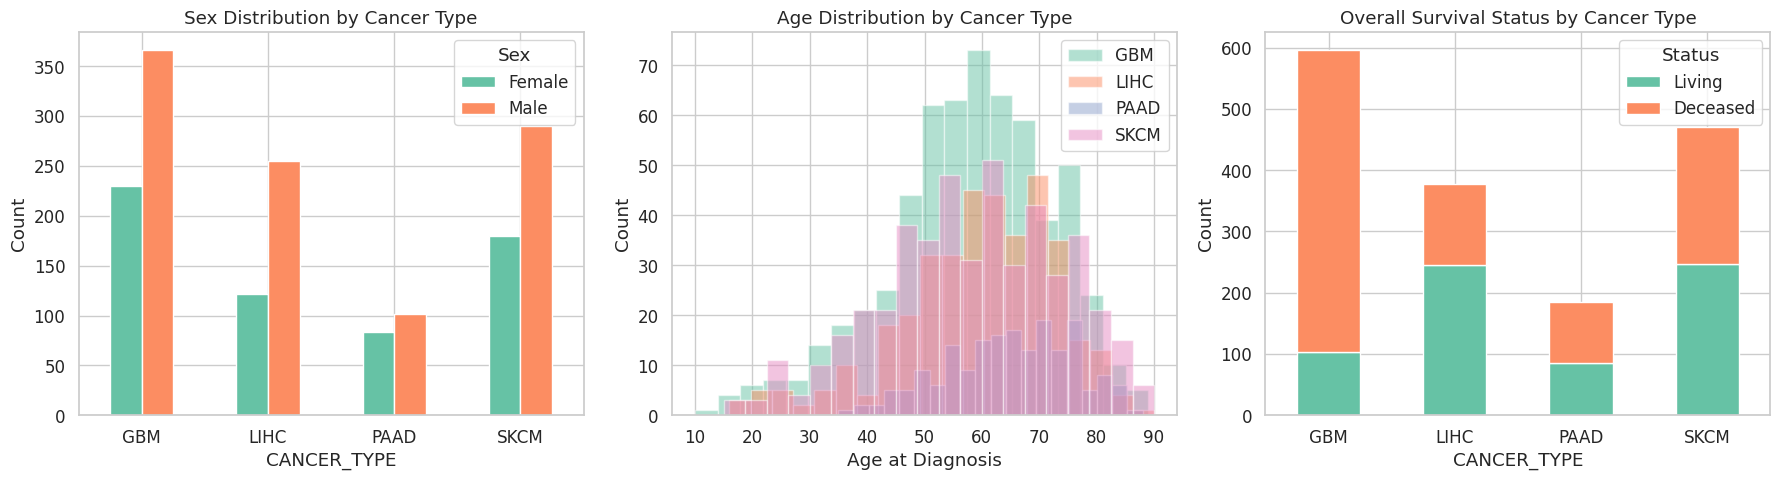

In [16]:
# --- Demographics: Sex distribution by cancer type ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sex
if 'SEX' in clinical_clean.columns:
    ct_sex = pd.crosstab(clinical_clean['CANCER_TYPE'], clinical_clean['SEX'])
    ct_sex.plot(kind='bar', ax=axes[0], rot=0)
    axes[0].set_title('Sex Distribution by Cancer Type')
    axes[0].set_ylabel('Count')
    axes[0].legend(title='Sex')

# Age distribution
if 'AGE' in clinical_clean.columns:
    for ct_name in clinical_clean['CANCER_TYPE'].unique():
        subset = clinical_clean[clinical_clean['CANCER_TYPE'] == ct_name]['AGE'].dropna()
        axes[1].hist(subset, bins=20, alpha=0.5, label=ct_name, edgecolor='white')
    axes[1].set_title('Age Distribution by Cancer Type')
    axes[1].set_xlabel('Age at Diagnosis')
    axes[1].set_ylabel('Count')
    axes[1].legend()

# Overall survival status
if 'OS_EVENT' in clinical_clean.columns:
    ct_os = pd.crosstab(clinical_clean['CANCER_TYPE'], clinical_clean['OS_EVENT'])
    ct_os.columns = ['Living', 'Deceased']
    ct_os.plot(kind='bar', stacked=True, ax=axes[2], rot=0, color=['#66c2a5', '#fc8d62'])
    axes[2].set_title('Overall Survival Status by Cancer Type')
    axes[2].set_ylabel('Count')
    axes[2].legend(title='Status')

plt.tight_layout()
plt.show()

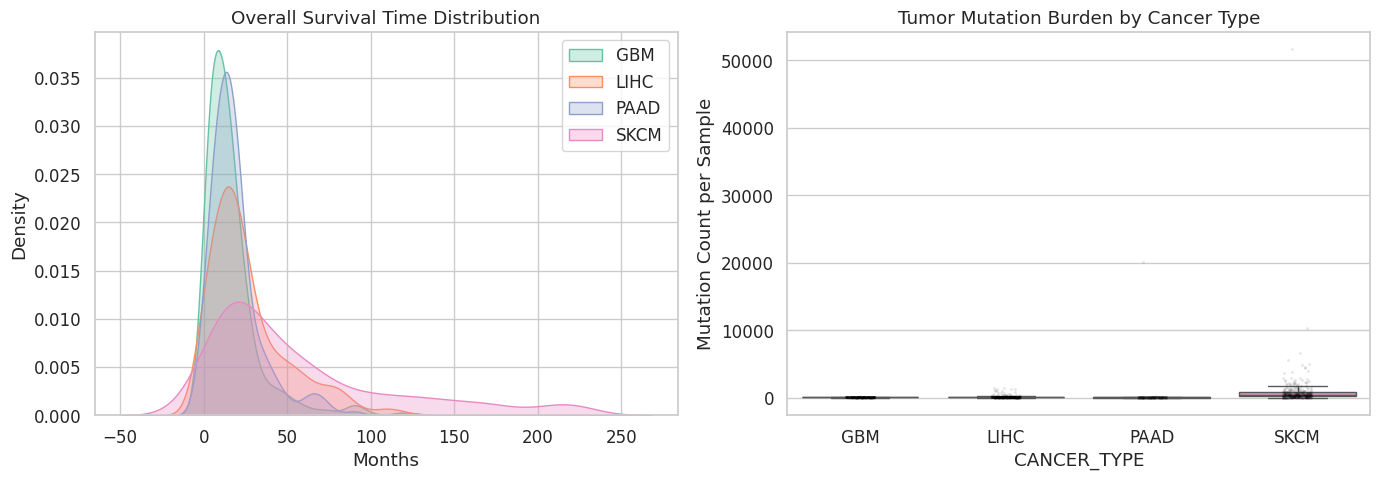

In [17]:
# --- Survival time distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'OS_MONTHS' in clinical_clean.columns:
    for ct_name in clinical_clean['CANCER_TYPE'].unique():
        subset = clinical_clean[clinical_clean['CANCER_TYPE'] == ct_name]['OS_MONTHS'].dropna()
        sns.kdeplot(subset, ax=axes[0], label=ct_name, fill=True, alpha=0.3)
    axes[0].set_title('Overall Survival Time Distribution')
    axes[0].set_xlabel('Months')
    axes[0].legend()

# Mutation burden distribution
sns.boxplot(data=mutation_burden_all, x='CANCER_TYPE', y='MUTATION_COUNT', ax=axes[1],
            palette='Set2', showfliers=False)
sns.stripplot(data=mutation_burden_all, x='CANCER_TYPE', y='MUTATION_COUNT', ax=axes[1],
              color='black', alpha=0.1, size=2)
axes[1].set_title('Tumor Mutation Burden by Cancer Type')
axes[1].set_ylabel('Mutation Count per Sample')

plt.tight_layout()
plt.show()

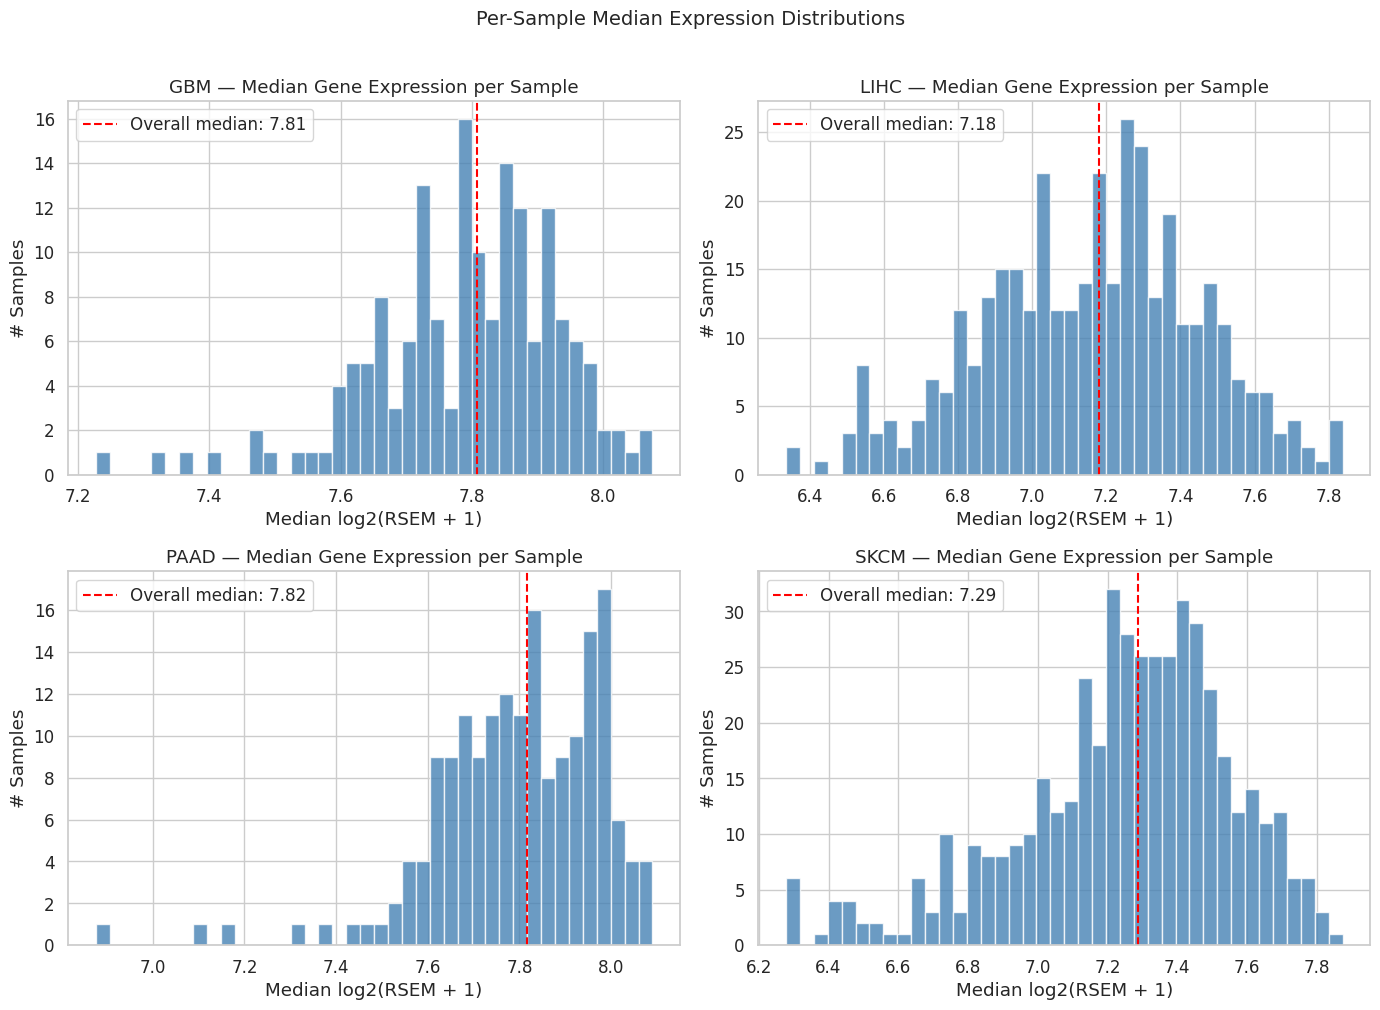

In [18]:
# --- Gene expression distributions (log2 RSEM) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, ct in zip(axes.flat, CANCER_TYPES):
    # Sample median expression per sample
    sample_medians = expr_log2[ct].median(axis=0)
    ax.hist(sample_medians, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{CANCER_LABELS[ct]} — Median Gene Expression per Sample')
    ax.set_xlabel('Median log2(RSEM + 1)')
    ax.set_ylabel('# Samples')
    ax.axvline(sample_medians.median(), color='red', linestyle='--', label=f'Overall median: {sample_medians.median():.2f}')
    ax.legend()

plt.suptitle('Per-Sample Median Expression Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

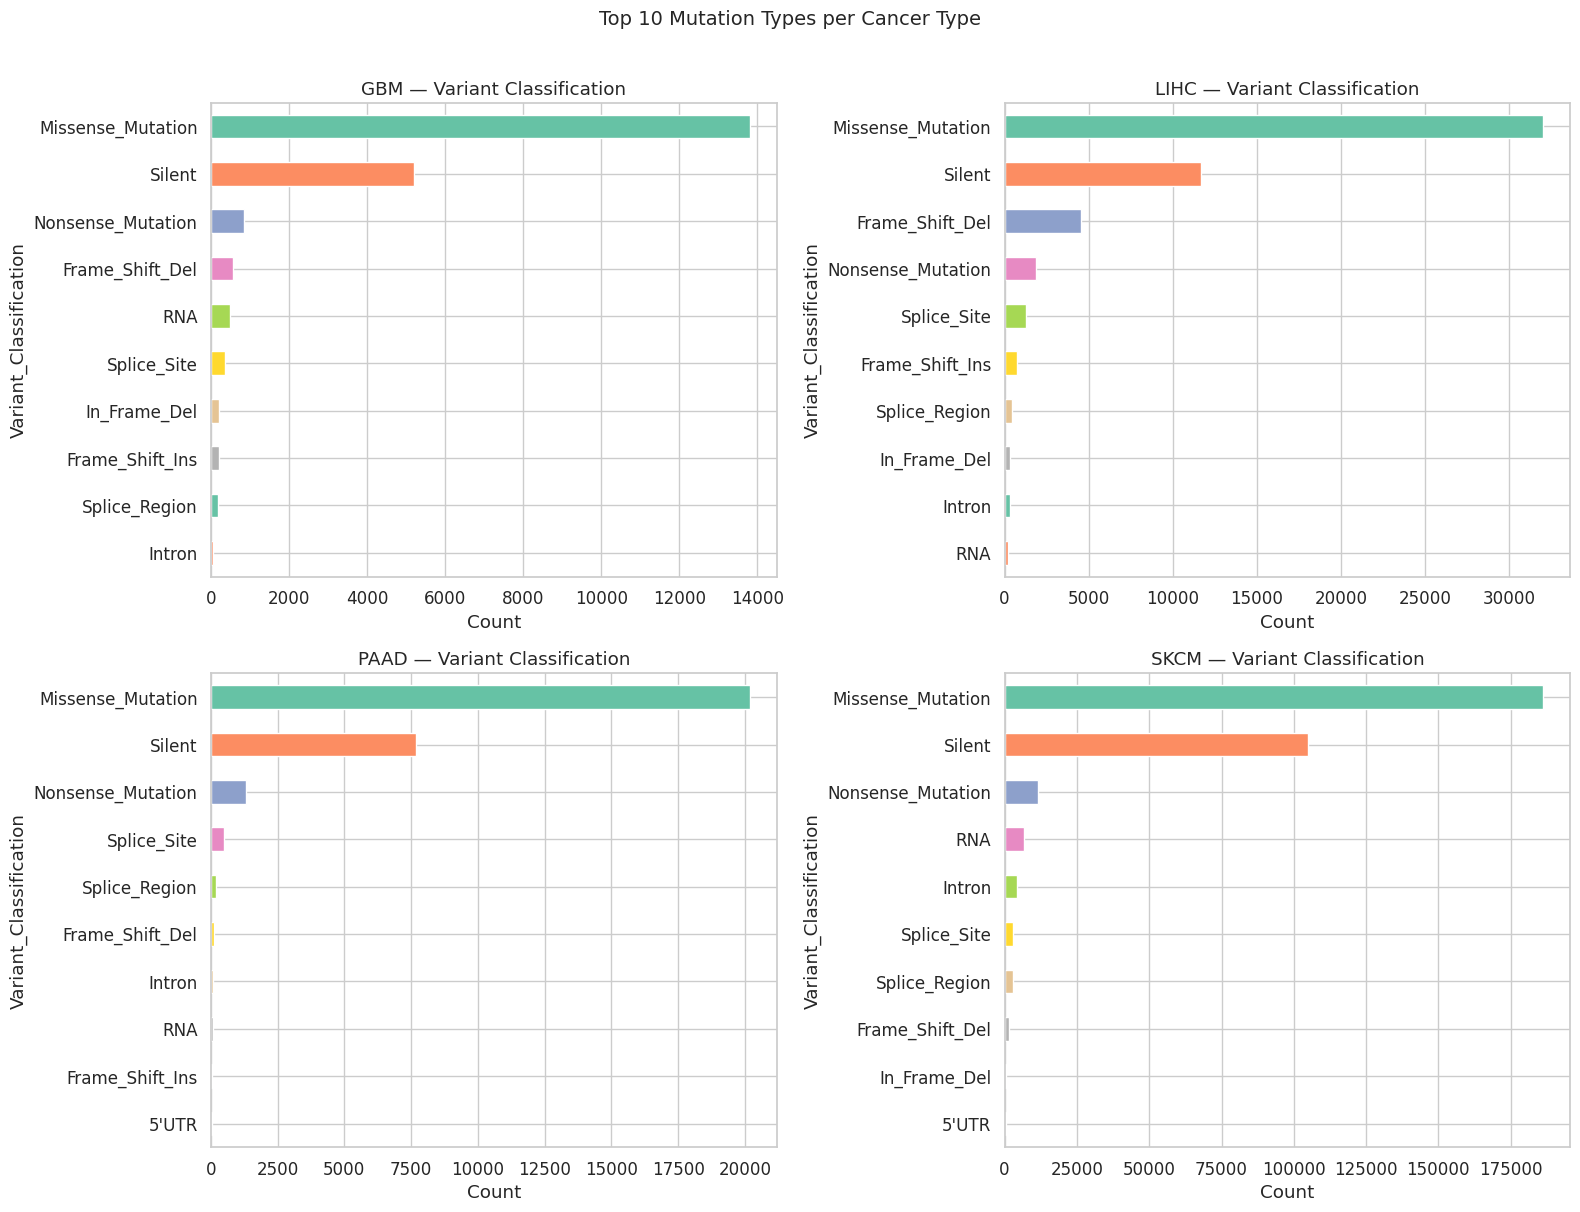

In [19]:
# --- Mutation type breakdown ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, ct in zip(axes.flat, CANCER_TYPES):
    df = mutation_data[ct]
    if 'Variant_Classification' in df.columns:
        vc = df['Variant_Classification'].value_counts().head(10)
        vc.plot(kind='barh', ax=ax, color=sns.color_palette("Set2", len(vc)))
        ax.set_title(f'{CANCER_LABELS[ct]} — Variant Classification')
        ax.set_xlabel('Count')
        ax.invert_yaxis()

plt.suptitle('Top 10 Mutation Types per Cancer Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 10. Bivariate and Multivariate Analysis

Explore relationships between clinical variables and across data modalities.

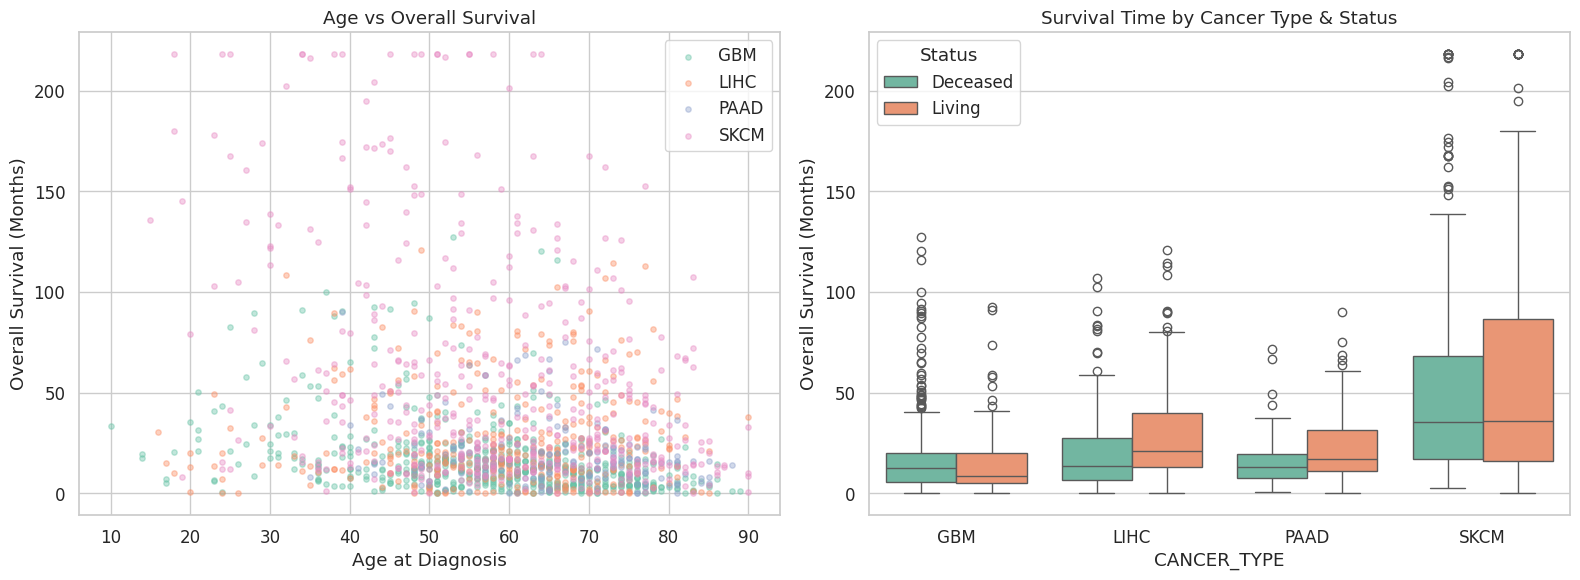

In [20]:
# --- Age vs Overall Survival by Cancer Type ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Age vs OS_MONTHS coloured by cancer type
if all(c in clinical_clean.columns for c in ['AGE', 'OS_MONTHS', 'CANCER_TYPE']):
    for ct_name in clinical_clean['CANCER_TYPE'].cat.categories:
        subset = clinical_clean[clinical_clean['CANCER_TYPE'] == ct_name]
        axes[0].scatter(subset['AGE'], subset['OS_MONTHS'], alpha=0.4, s=15, label=ct_name)
    axes[0].set_xlabel('Age at Diagnosis')
    axes[0].set_ylabel('Overall Survival (Months)')
    axes[0].set_title('Age vs Overall Survival')
    axes[0].legend()

# Box plot: OS_MONTHS by cancer type and survival status
if all(c in clinical_clean.columns for c in ['OS_MONTHS', 'CANCER_TYPE', 'OS_EVENT']):
    clinical_clean['Status'] = clinical_clean['OS_EVENT'].map({0: 'Living', 1: 'Deceased'})
    sns.boxplot(data=clinical_clean, x='CANCER_TYPE', y='OS_MONTHS', hue='Status',
                ax=axes[1], palette=['#66c2a5', '#fc8d62'])
    axes[1].set_title('Survival Time by Cancer Type & Status')
    axes[1].set_ylabel('Overall Survival (Months)')

plt.tight_layout()
plt.show()

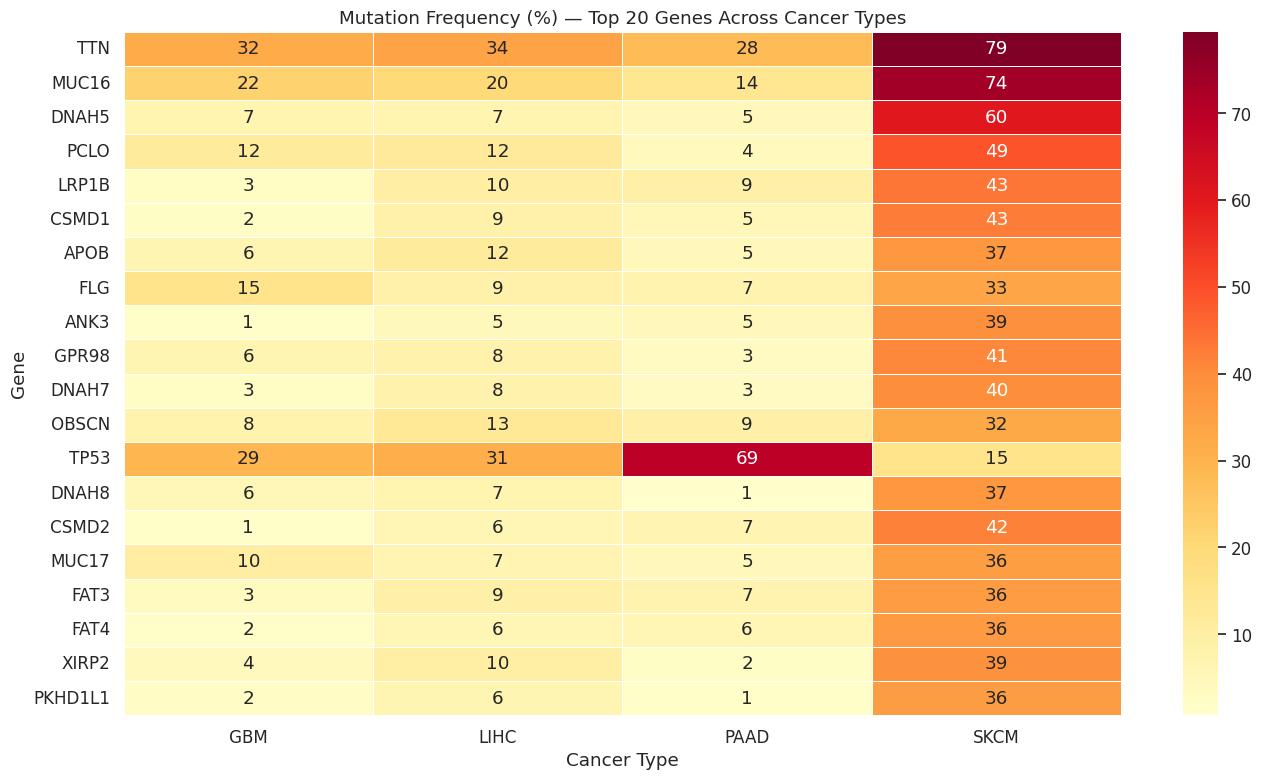

In [21]:
# --- Top mutated genes: Oncoplot-style comparison ---
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 20 most mutated genes across all cancer types
all_genes = pd.concat([mutation_data[ct]['Hugo_Symbol'] for ct in CANCER_TYPES])
top20_genes = all_genes.value_counts().head(20).index.tolist()

# Compute mutation frequency (% of samples mutated) per gene per cancer type
freq_matrix = pd.DataFrame(index=top20_genes)
for ct in CANCER_TYPES:
    df = mutation_data[ct]
    n_samples = df['Tumor_Sample_Barcode'].nunique()
    gene_counts = df[df['Hugo_Symbol'].isin(top20_genes)].groupby('Hugo_Symbol')['Tumor_Sample_Barcode'].nunique()
    freq_matrix[CANCER_LABELS[ct]] = (gene_counts / n_samples * 100).reindex(top20_genes).fillna(0)

sns.heatmap(freq_matrix, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Mutation Frequency (%) — Top 20 Genes Across Cancer Types')
ax.set_ylabel('Gene')
ax.set_xlabel('Cancer Type')
plt.tight_layout()
plt.show()

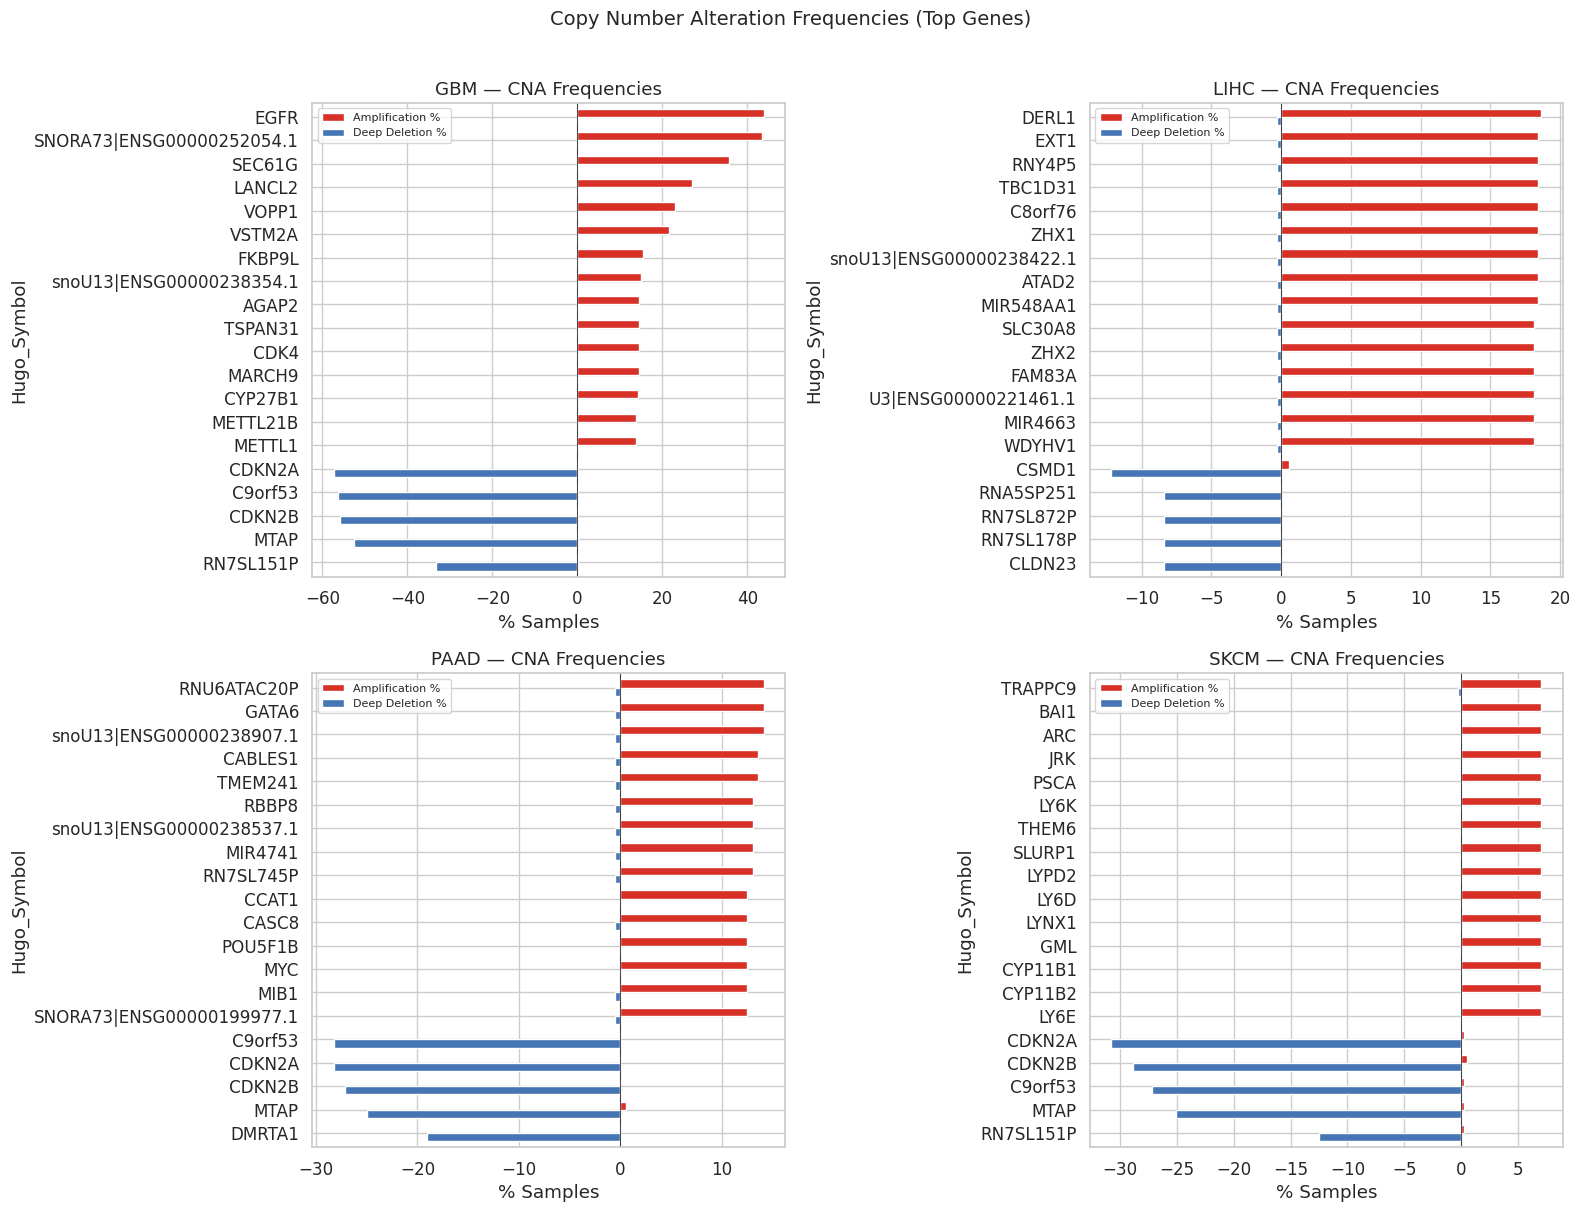

In [22]:
# --- CNA landscape: amplification and deletion frequencies ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, ct in zip(axes.flat, CANCER_TYPES):
    df = cna_data[ct]
    n_samples = df.shape[1]

    # CNA values: -2 = deep del, -1 = shallow del, 0 = diploid, 1 = gain, 2 = amp
    amp_freq = (df == 2).sum(axis=1) / n_samples * 100
    del_freq = (df == -2).sum(axis=1) / n_samples * 100

    # Top 15 amplified + top 15 deleted
    top_amp = amp_freq.nlargest(15)
    top_del = del_freq.nlargest(15)

    genes = list(top_amp.index) + [g for g in top_del.index if g not in top_amp.index][:5]
    plot_data = pd.DataFrame({
        'Amplification %': amp_freq.reindex(genes).fillna(0),
        'Deep Deletion %': -del_freq.reindex(genes).fillna(0)  # negative for visual
    })

    plot_data.plot(kind='barh', ax=ax, color=['#d73027', '#4575b4'], width=0.7)
    ax.set_title(f'{CANCER_LABELS[ct]} — CNA Frequencies')
    ax.set_xlabel('% Samples')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.suptitle('Copy Number Alteration Frequencies (Top Genes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

Examine correlations within clinical features and across the most variable genes in expression data.

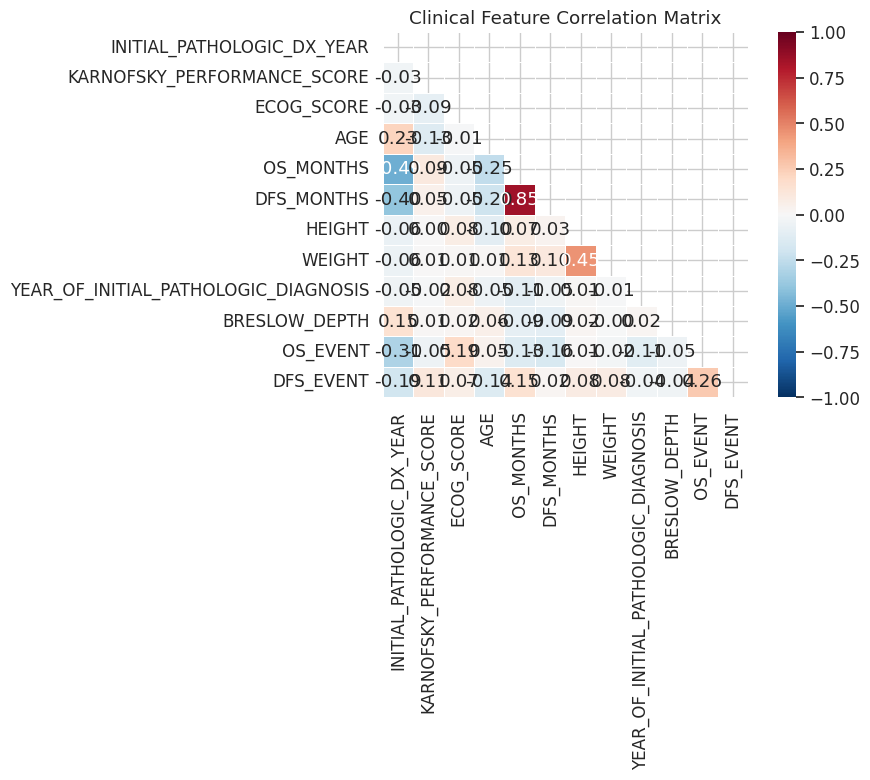

Strong correlations (|r| > 0.5):
DFS_MONTHS  OS_MONTHS    0.847986


In [23]:
# --- Clinical feature correlations ---
numeric_clinical = clinical_clean.select_dtypes(include=[np.number])
# Drop columns with zero variance
numeric_clinical = numeric_clinical.loc[:, numeric_clinical.std() > 0]

fig, ax = plt.subplots(figsize=(10, 8))
corr = numeric_clinical.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Clinical Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Highlight strong correlations
strong = corr.where(mask == False).stack()
strong = strong[(strong.abs() > 0.5) & (strong.abs() < 1.0)].sort_values(ascending=False)
if len(strong) > 0:
    print("Strong correlations (|r| > 0.5):")
    print(strong.to_string())
else:
    print("No strong correlations found among clinical numeric features.")

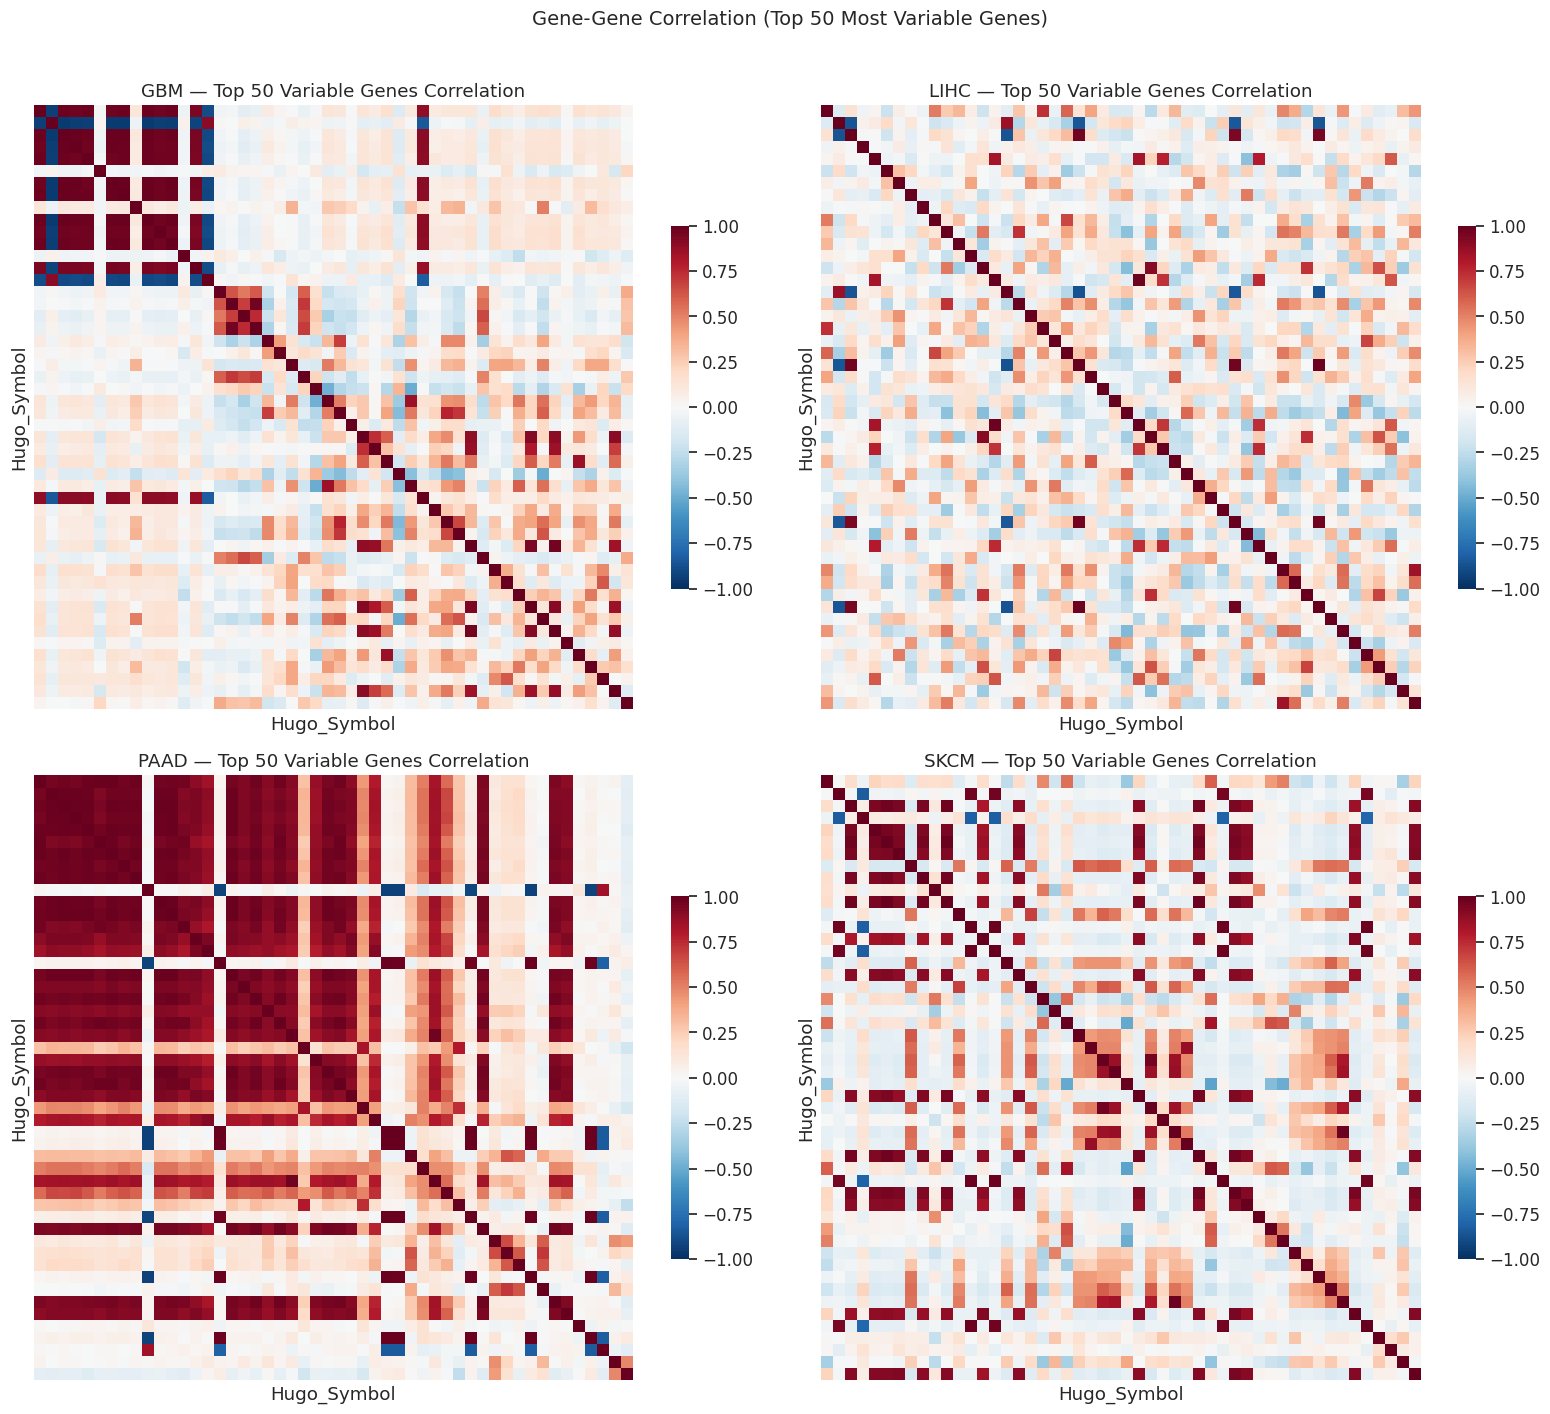

In [24]:
# --- Gene expression correlation: top 50 most variable genes per cancer type ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, ct in zip(axes.flat, CANCER_TYPES):
    df = expr_log2[ct]
    # Select top 50 genes by variance
    gene_var = df.var(axis=1).nlargest(50)
    top_genes_df = df.loc[gene_var.index]
    corr = top_genes_df.T.corr()
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, xticklabels=False, yticklabels=False,
                vmin=-1, vmax=1, cbar_kws={'shrink': 0.6})
    ax.set_title(f'{CANCER_LABELS[ct]} — Top 50 Variable Genes Correlation')

plt.suptitle('Gene-Gene Correlation (Top 50 Most Variable Genes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 12. Save Preprocessed Data

Export cleaned clinical data and processed expression matrices for downstream modelling.

In [25]:
# --- Save preprocessed outputs ---
out_dir = os.path.join(DATA_DIR, 'preprocessed')
os.makedirs(out_dir, exist_ok=True)

# 1. Cleaned clinical data (combined)
clinical_out = os.path.join(out_dir, 'clinical_all_clean.csv')
clinical_clean.to_csv(clinical_out, index=False)
print(f"✓ Saved cleaned clinical data → {clinical_out}  ({clinical_clean.shape})")

# 2. Mutation burden per sample
burden_out = os.path.join(out_dir, 'mutation_burden.csv')
mutation_burden_all.to_csv(burden_out, index=False)
print(f"✓ Saved mutation burden → {burden_out}  ({mutation_burden_all.shape})")

# 3. Log2-transformed expression matrices (one per cancer type)
for ct in CANCER_TYPES:
    expr_out = os.path.join(out_dir, f'expr_log2_{CANCER_LABELS[ct].lower()}.csv')
    expr_log2[ct].to_csv(expr_out)
    print(f"✓ Saved {CANCER_LABELS[ct]} expression → {expr_out}  ({expr_log2[ct].shape})")

print(f"\nAll preprocessed data saved to: {out_dir}/")
print("Files:")
for f in sorted(os.listdir(out_dir)):
    size_mb = os.path.getsize(os.path.join(out_dir, f)) / 1024 / 1024
    print(f"  {f:45s} ({size_mb:.1f} MB)")

✓ Saved cleaned clinical data → data/preprocessed/clinical_all_clean.csv  ((1628, 57))
✓ Saved mutation burden → data/preprocessed/mutation_burden.csv  ((1181, 3))
✓ Saved GBM expression → data/preprocessed/expr_log2_gbm.csv  ((20514, 166))
✓ Saved LIHC expression → data/preprocessed/expr_log2_lihc.csv  ((20514, 373))
✓ Saved PAAD expression → data/preprocessed/expr_log2_paad.csv  ((20514, 179))
✓ Saved SKCM expression → data/preprocessed/expr_log2_skcm.csv  ((20514, 472))

All preprocessed data saved to: data/preprocessed/
Files:
  clinical_all_clean.csv                        (0.7 MB)
  expr_log2_gbm.csv                             (52.8 MB)
  expr_log2_lihc.csv                            (115.0 MB)
  expr_log2_paad.csv                            (57.7 MB)
  expr_log2_skcm.csv                            (147.7 MB)
  mutation_burden.csv                           (0.0 MB)


## 13. Per-Patient Multi-Omic Table

Join clinical data, mutation burden, expression (top 500 most variable genes), and CNA into a single flat patient-level CSV for downstream ML/survival analysis.

**Sample selection rule:** primary tumor samples (`SAMPLE_ID` ending in `-01`); when a patient has multiple primaries, keep the first in sorted order.

In [26]:
# ── 13.1  Select one primary tumor sample per patient ────────────────────────
# Primary = SAMPLE_ID 4th field == '01'  (e.g. TCGA-02-0001-01)
sample_all['IS_PRIMARY'] = sample_all['SAMPLE_ID'].str.split('-').str[3].eq('01')

primary_samples = (
    sample_all[sample_all['IS_PRIMARY']]
    .sort_values('SAMPLE_ID')                          # deterministic order
    .drop_duplicates(subset='PATIENT_ID', keep='first')
    [['PATIENT_ID', 'SAMPLE_ID', 'CANCER_TYPE']]
    .reset_index(drop=True)
)

print(f"Patients with ≥1 primary sample : {len(primary_samples)}")
print(f"Total patients in clinical_clean: {len(clinical_clean)}")
print(f"\nPrimary samples per cancer type:")
print(primary_samples['CANCER_TYPE'].value_counts().to_string())


Patients with ≥1 primary sample : 1277
Total patients in clinical_clean: 1628

Primary samples per cancer type:
CANCER_TYPE
GBM     606
LIHC    377
PAAD    185
SKCM    109


In [27]:
# ── 13.2  Fallback: for patients with no primary (-01), use next-best sample ─
# SKCM has mostly metastatic (-06) samples — without fallback we'd lose ~360 patients.

# All patients covered so far
covered = set(primary_samples['PATIENT_ID'])

# Patients in clinical_clean that still lack a selected sample
missing_pts = set(clinical_clean['PATIENT_ID']) - covered

fallback_samples = (
    sample_all[sample_all['PATIENT_ID'].isin(missing_pts)]
    .sort_values('SAMPLE_ID')
    .drop_duplicates(subset='PATIENT_ID', keep='first')
    [['PATIENT_ID', 'SAMPLE_ID', 'CANCER_TYPE']]
    .assign(IS_FALLBACK=True)
)

# Tag primary set
primary_samples_tagged = primary_samples.assign(IS_FALLBACK=False)

# Combine
selected_samples = pd.concat(
    [primary_samples_tagged, fallback_samples], ignore_index=True
)

print(f"Primary samples selected  : {(~selected_samples['IS_FALLBACK']).sum()}")
print(f"Fallback samples selected : {selected_samples['IS_FALLBACK'].sum()}")
print(f"Total selected            : {len(selected_samples)}")
print(f"\nBreakdown by cancer type:")
print(selected_samples.groupby('CANCER_TYPE')['IS_FALLBACK']
      .value_counts().unstack(fill_value=0).rename(columns={False:'primary', True:'fallback'}))


Primary samples selected  : 1277
Fallback samples selected : 361
Total selected            : 1638

Breakdown by cancer type:
IS_FALLBACK  primary  fallback
CANCER_TYPE                   
GBM              606         0
LIHC             377         0
PAAD             185         0
SKCM             109       361


In [29]:
# ── 13.3  Top-500 most variable genes (expression) across all cancers ────────
TOP_N_GENES = 500

# Build a combined sample → gene matrix using only selected samples
expr_pieces = []
for ct in CANCER_TYPES:
    ct_label = CANCER_LABELS[ct]                      # e.g. 'gbm_tcga' → 'GBM'
    sel_sids = selected_samples.loc[
        selected_samples['CANCER_TYPE'] == ct_label, 'SAMPLE_ID'
    ]
    # Keep only samples present in the expression matrix
    avail = [s for s in sel_sids if s in expr_log2[ct].columns]
    if avail:
        piece = expr_log2[ct][avail].T                # samples × genes
        expr_pieces.append(piece)
        print(f"  {ct_label}: {len(avail)} samples with expression data")

expr_combined = pd.concat(expr_pieces, axis=0)        # all samples × genes
print(f"\nCombined expression matrix: {expr_combined.shape}  (samples × genes)")

# Variance per gene, pick top N
gene_variance = expr_combined.var(axis=0).sort_values(ascending=False)
top500_genes   = gene_variance.head(TOP_N_GENES).index.tolist()
print(f"Top-{TOP_N_GENES} most variable genes selected  (min var = {gene_variance[top500_genes[-1]]:.3f})")

# Slice to top genes → expression feature table indexed by SAMPLE_ID
expr_features = expr_combined[top500_genes].copy()
expr_features.index.name = 'SAMPLE_ID'
expr_features.columns = [f'EXPR_{g}' for g in expr_features.columns]
print(f"Expression feature table  : {expr_features.shape}")


  GBM: 153 samples with expression data
  LIHC: 371 samples with expression data
  PAAD: 178 samples with expression data
  SKCM: 464 samples with expression data

Combined expression matrix: (1166, 20522)  (samples × genes)
Top-500 most variable genes selected  (min var = 14.067)
Expression feature table  : (1166, 500)


In [30]:
# ── 13.4  CNA features (same top-500 gene set) ───────────────────────────────
# Reuse the same top500_genes list so expression and CNA share the same gene space.
# CNA values: -2 deep del, -1 shallow del, 0 neutral, 1 gain, 2 amplification

cna_pieces = []
for ct in CANCER_TYPES:
    ct_label = CANCER_LABELS[ct]
    sel_sids = selected_samples.loc[
        selected_samples['CANCER_TYPE'] == ct_label, 'SAMPLE_ID'
    ]
    avail = [s for s in sel_sids if s in cna_data[ct].columns]
    if not avail:
        continue
    # cna_data[ct] has Hugo_Symbol as index; keep only top500 genes
    shared_genes = [g for g in top500_genes if g in cna_data[ct].index]
    piece = cna_data[ct].loc[shared_genes, avail].T   # samples × genes
    cna_pieces.append(piece)
    print(f"  {ct_label}: {len(avail)} samples  |  {len(shared_genes)}/{TOP_N_GENES} genes in CNA")

cna_combined = pd.concat(cna_pieces, axis=0)
cna_combined.index.name = 'SAMPLE_ID'

# Fill missing genes with 0 (neutral)
cna_combined = cna_combined.reindex(columns=top500_genes, fill_value=0)
cna_combined.columns = [f'CNA_{g}' for g in cna_combined.columns]

print(f"\nCNA feature table         : {cna_combined.shape}")


  GBM: 577 samples  |  462/500 genes in CNA
  LIHC: 370 samples  |  462/500 genes in CNA
  PAAD: 184 samples  |  462/500 genes in CNA
  SKCM: 360 samples  |  462/500 genes in CNA

CNA feature table         : (1491, 500)


In [32]:
# ── 13.5  Assemble per-patient multi-omic table ───────────────────────────────
# Anchor = clinical_clean (patient-level)
# Join chain:
#   clinical_clean  +PATIENT_ID→  selected_samples  +SAMPLE_ID→
#   mutation_burden_all  +SAMPLE_ID→  expr_features  +SAMPLE_ID→  cna_combined

# Step 1: attach selected sample ID to each patient
df_mo = clinical_clean.merge(
    selected_samples[['PATIENT_ID', 'SAMPLE_ID', 'IS_FALLBACK']],
    on='PATIENT_ID', how='left'
)

# Step 2: mutation burden  (Tumor_Sample_Barcode == SAMPLE_ID)
mb = (mutation_burden_all
      .rename(columns={'Tumor_Sample_Barcode': 'SAMPLE_ID',
                       'MUTATION_COUNT': 'MUTATION_BURDEN'})
      [['SAMPLE_ID', 'MUTATION_BURDEN']])
df_mo = df_mo.merge(mb, on='SAMPLE_ID', how='left')

# Step 3: expression features (index = SAMPLE_ID)
df_mo = df_mo.merge(
    expr_features.reset_index(),
    on='SAMPLE_ID', how='left'
)

# Step 4: CNA features (index = SAMPLE_ID)
df_mo = df_mo.merge(
    cna_combined.reset_index(),
    on='SAMPLE_ID', how='left'
)

expr_col_example = [c for c in df_mo.columns if c.startswith('EXPR_')][0]
cna_col_example  = [c for c in df_mo.columns if c.startswith('CNA_')][0]

print(f"Multi-omic table shape : {df_mo.shape}  (patients × features)")
print(f"\nColumn groups:")
print(f"  Clinical / metadata: {sum(1 for c in df_mo.columns if not c.startswith(('EXPR_','CNA_')))}")
print(f"  Expression (EXPR_) : {sum(1 for c in df_mo.columns if c.startswith('EXPR_'))}")
print(f"  CNA (CNA_)         : {sum(1 for c in df_mo.columns if c.startswith('CNA_'))}")
print(f"\nData coverage per omic layer:")
print(f"  Has SAMPLE_ID      : {df_mo['SAMPLE_ID'].notna().sum()} / {len(df_mo)}")
print(f"  Has mutation burden: {df_mo['MUTATION_BURDEN'].notna().sum()} / {len(df_mo)}")
print(f"  Has expression     : {df_mo[expr_col_example].notna().sum()} / {len(df_mo)}")
print(f"  Has CNA            : {df_mo[cna_col_example].notna().sum()} / {len(df_mo)}")
print(f"  Has all 3 omics    : {df_mo[['MUTATION_BURDEN', expr_col_example, cna_col_example]].notna().all(axis=1).sum()} / {len(df_mo)}")


Multi-omic table shape : (1628, 1060)  (patients × features)

Column groups:
  Clinical / metadata: 60
  Expression (EXPR_) : 500
  CNA (CNA_)         : 500

Data coverage per omic layer:
  Has SAMPLE_ID      : 1628 / 1628
  Has mutation burden: 1169 / 1628
  Has expression     : 1165 / 1628
  Has CNA            : 1487 / 1628
  Has all 3 omics    : 929 / 1628


In [33]:
# ── 13.6  Save multi-omic table ──────────────────────────────────────────────
mo_out = os.path.join(out_dir, 'patient_multiomic.csv')
df_mo.to_csv(mo_out, index=False)
size_mb = os.path.getsize(mo_out) / 1024 / 1024
print(f"✓ Saved patient_multiomic.csv  →  {mo_out}")
print(f"  Shape : {df_mo.shape[0]} patients × {df_mo.shape[1]} features")
print(f"  Size  : {size_mb:.1f} MB")

# Column manifest
col_groups = {
    'ID / metadata'    : [c for c in df_mo.columns if c in ['PATIENT_ID','SAMPLE_ID','CANCER_TYPE','IS_FALLBACK']],
    'Survival targets' : [c for c in df_mo.columns if c in ['OS_STATUS','OS_MONTHS','OS_EVENT','DFS_STATUS','DFS_MONTHS','DFS_EVENT']],
    'Clinical covars'  : [c for c in df_mo.columns if not c.startswith(('EXPR_','CNA_'))
                           and c not in ['PATIENT_ID','SAMPLE_ID','CANCER_TYPE','IS_FALLBACK',
                                         'OS_STATUS','OS_MONTHS','OS_EVENT','DFS_STATUS','DFS_MONTHS','DFS_EVENT',
                                         'MUTATION_BURDEN']],
    'Mutation burden'  : ['MUTATION_BURDEN'],
    'Expression'       : [c for c in df_mo.columns if c.startswith('EXPR_')],
    'CNA'              : [c for c in df_mo.columns if c.startswith('CNA_')],
}
print("\nColumn manifest:")
for grp, cols in col_groups.items():
    print(f"  {grp:20s}: {len(cols):4d} columns")


✓ Saved patient_multiomic.csv  →  data/preprocessed/patient_multiomic.csv
  Shape : 1628 patients × 1060 features
  Size  : 12.4 MB

Column manifest:
  ID / metadata       :    4 columns
  Survival targets    :    6 columns
  Clinical covars     :   49 columns
  Mutation burden     :    1 columns
  Expression          :  500 columns
  CNA                 :  500 columns


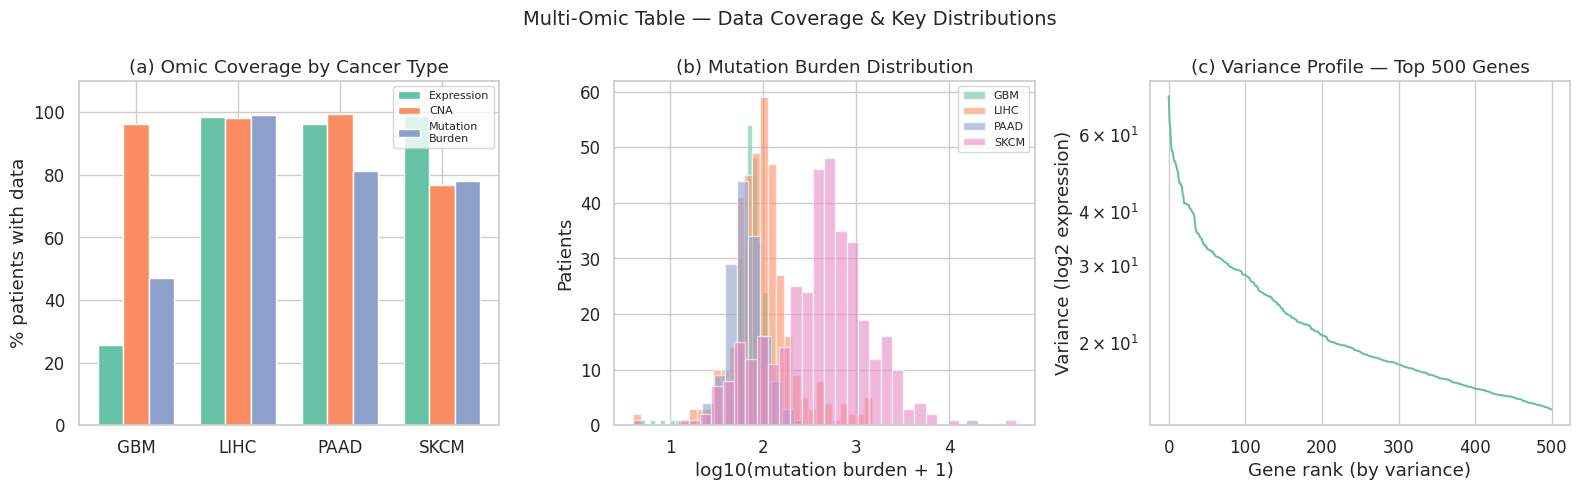

✓ Saved multiomic_overview.png


In [34]:
# ── 13.7  Overview visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Multi-Omic Table — Data Coverage & Key Distributions', fontsize=14)

# (a) Data availability per omic layer, per cancer type
omic_cols = {
    'Expression': expr_col_example,
    'CNA'        : cna_col_example,
    'Mutation\nBurden': 'MUTATION_BURDEN',
}
cancer_labels_order = [CANCER_LABELS[ct] for ct in CANCER_TYPES]
coverage = {omic: [] for omic in omic_cols}
for ct_label in cancer_labels_order:
    sub = df_mo[df_mo['CANCER_TYPE'] == ct_label]
    for omic, col in omic_cols.items():
        coverage[omic].append(sub[col].notna().mean() * 100)

x = np.arange(len(cancer_labels_order))
w = 0.25
for i, (omic, vals) in enumerate(coverage.items()):
    axes[0].bar(x + i*w, vals, width=w, label=omic)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(cancer_labels_order)
axes[0].set_ylabel('% patients with data')
axes[0].set_title('(a) Omic Coverage by Cancer Type')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)

# (b) Mutation burden distribution (log10)  per cancer type
for ct_label in cancer_labels_order:
    vals = df_mo.loc[df_mo['CANCER_TYPE'] == ct_label, 'MUTATION_BURDEN'].dropna()
    axes[1].hist(np.log10(vals + 1), bins=30, alpha=0.6, label=ct_label)
axes[1].set_xlabel('log10(mutation burden + 1)')
axes[1].set_ylabel('Patients')
axes[1].set_title('(b) Mutation Burden Distribution')
axes[1].legend(fontsize=8)

# (c) Expression variance of selected genes (ranked)
gene_vars = expr_features.var(axis=0).sort_values(ascending=False).values
axes[2].plot(range(len(gene_vars)), gene_vars, lw=1.5)
axes[2].set_xlabel('Gene rank (by variance)')
axes[2].set_ylabel('Variance (log2 expression)')
axes[2].set_title('(c) Variance Profile — Top 500 Genes')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'multiomic_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved multiomic_overview.png")
